In [1]:
# various import statements
import os
import inspect
import seaborn
import matplotlib
import matplotlib.pyplot as plt
import torch
import scanpy as sc
import pyro

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import sys
import antipode
from antipode.antipode_model import *
import antipode.model_functions
from antipode.model_functions import *
import antipode.model_distributions
from antipode.model_distributions import *
import antipode.model_modules
from antipode.model_modules import *
import antipode.train_utils
from antipode.train_utils import *
import antipode.plotting
from antipode.plotting import *

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU is available
Number of GPUs: 1
GPU Name: NVIDIA A100-PCIE-40GB


In [2]:
import importlib
antipode = importlib.reload(antipode)

In [3]:
adata=sc.read_h5ad(os.path.expanduser('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/data/taxtest/HvQvM/HvQvMall_cere_clean_nodoublets.h5ad'),backed='r')
#adata=sc.read_h5ad(os.path.expanduser('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/data/taxtest/HvQvM/HvQvMall_part0.h5ad'),backed='r')

batch_key='batch_name'
discov_key='species'
layer_key='spliced'

In [10]:
adata.obs['female']=adata.obs['batch_name'].replace(pd.read_csv('/home/matthew.schmitz/Matthew/data/taxtest/extra/inferred_sex.csv',index_col=0).to_dict()['female'])
adata.obsm['discov_onehot']=np.concatenate([antipode.model_functions.numpy_onehot(adata.obs['species'].cat.codes),antipode.model_functions.numpy_onehot(adata.obs['female'].astype('category').cat.codes)],axis=-1)
adata.obsm['batch_onehot']=antipode.model_functions.numpy_onehot(adata.obs['batch_name'].cat.codes)

/scratch/fast/16236442/ipykernel_279149/1965958641.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.obs['female']=adata.obs['batch_name'].replace(pd.read_csv('/home/matthew.schmitz/Matthew/data/taxtest/extra/inferred_sex.csv',index_col=0).to_dict()['female'])
/scratch/fast/16236442/ipykernel_279149/1965958641.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['female']=adata.obs['batch_name'].replace(pd.read_csv('/home/matthew.schmitz/Matthew/data/taxtest/extra/inferred_sex.csv',index_col=0).to_dict()['female'])


In [11]:
num_var=adata.shape[1]
batch_size=32
level_sizes=[1,50,300]
num_latent=200
steps=0
max_steps=300000
num_particles=3
print_every=5000

# Clear Pyro param store so we don't conflict with previous run
try:
    pyro.clear_param_store()
    del antipode_model
    torch.cuda.empty_cache()
except:
    pass
# Fix random number seed to a lucky number
pyro.util.set_rng_seed(13)
# Enable optional validation warnings
pyro.enable_validation(False)

model_tag='1.9.1.8.3_Dev_SpeciesPlusSex'
# Instantiate instance of model/guide and various neural networks
antipode_model = antipode.antipode_model.ANTIPODE(num_latent=num_latent,level_sizes=level_sizes,bi_depth=2,num_batch_embed=10,psi_levels=[0.,1.,1.],
                adata=adata,discov_pair=('obsm','discov_onehot'),batch_pair=('obsm','batch_onehot'),layer=layer_key,
                use_psi=True,use_q_score=True,prior_scale=50.,sampler_category='species',dist_normalize=False,
                scale_init_val=0.01,loc_as_param=False,zdw_as_param=False,intercept_as_param=False)


INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


# Training Phase 1: Block Approximation

In [12]:
antipode_model.train_phase(phase=1,max_steps=max_steps,print_every=10000,num_particles=num_particles,device=device, max_learning_rate=1e-3, one_cycle_lr=True, batch_size=32)

  0%|          | 0/300000 [00:00<?, ?it/s]

fix scale factor


  0%|          | 1/300000 [00:00<65:01:24,  1.28it/s]/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/antipode_model.py:339: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  psi=psi*torch.tensor(self.psi_levels).to(s.device).unsqueeze(0)
/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/code/scANTIPODE/antipode/antipode_model.py:264: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  psi=psi*torch.tensor(self.psi_lev

In [13]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Wed May  8 23:32:37 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  | 00000000:64:00.0 Off |                    0 |
| N/A   35C    P0              35W / 250W |  14543MiB / 40960MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [14]:
antipode_model.store_outputs(device=device,prefix='')

In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

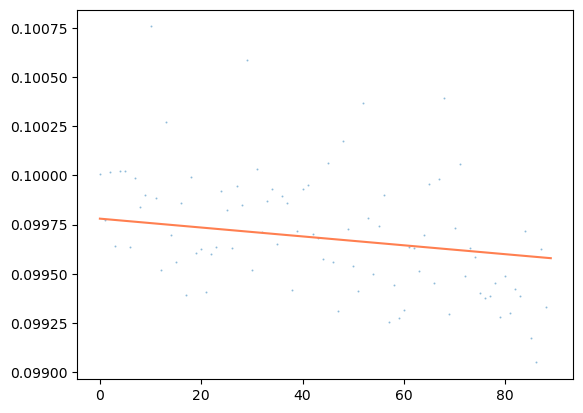

KeyError: 'categorical_mapping'

In [15]:
plot_loss(antipode_model.losses)
plot_gmm_heatmaps(antipode_model)
plot_d_hists(antipode_model)
plot_batch_embedding_pca(antipode_model)

In [ ]:
MDE_KEY = "X_antipode_MDE"
adata.obsm[MDE_KEY] = clip_latent_dimensions(scvi.model.utils.mde(adata.obsm['X_antipode'],init='random'),0.1)
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["antipode_cluster"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=['q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
)


In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

In [ ]:
antipode_model.save(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),save_anndata=False,prefix='p1_')

In [ ]:
# del adata
# antipode_model=ANTIPODE.load(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),prefix='p1_')
# antipode_model.train()
# adata=antipode_model.adata_manager.adata

# Training Phase 2: Intializing layered tree

In [ ]:
antipode_model.prepare_phase_2(epochs=2,device=device,dimension_reduction='X_antipode')

In [ ]:
antipode_model.train_phase(phase=2,max_steps=int(max_steps/2),print_every=10000,num_particles=num_particles,device=device, max_learning_rate=1e-3, one_cycle_lr=True, batch_size=32,freeze_encoder=True)

In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

In [ ]:
antipode_model.store_outputs(device=device,prefix='')

In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

In [ ]:
plot_loss(antipode_model.losses)
plot_gmm_heatmaps(antipode_model)
plot_d_hists(antipode_model)
plot_tree_edge_weights(antipode_model)

In [ ]:
MDE_KEY = "X_antipode_MDE"
#adata.obsm[MDE_KEY] = clip_latent_dimensions(scvi.model.utils.mde(adata.obsm['X_antipode'],init='random'),0.1)
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["antipode_cluster","kmeans"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=['q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'psi' in x],
    cmap='coolwarm',
    legend_loc='on data'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'level' in x],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

In [ ]:
antipode_model.save(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),save_anndata=False,prefix='p2_')

In [ ]:
# del adata
# antipode_model=ANTIPODE.load(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),prefix='p2_')
# antipode_model.train()
# adata=antipode_model.adata_manager.adata

In [ ]:
MDE_KEY = "X_antipode_MDE"
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["antipode_cluster"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=['q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'psi' in x],
    cmap='coolwarm',
    legend_loc='on data'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'level' in x],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


# Training Phase 3: Refining the final tree

In [ ]:
antipode_model.train_phase(phase=3,max_steps=max_steps,print_every=10000,num_particles=num_particles,device=device, max_learning_rate=1e-3, one_cycle_lr=True, batch_size=32)

In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

In [ ]:
plot_loss(antipode_model.losses)

In [ ]:
antipode_model.store_outputs(device=device,prefix='')

In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

In [ ]:
plot_loss(antipode_model.losses)
plot_gmm_heatmaps(antipode_model)
plot_d_hists(antipode_model)
plot_batch_embedding_pca(antipode_model)

In [ ]:
MDE_KEY = "X_antipode_MDE"
adata.obsm[MDE_KEY] = clip_latent_dimensions(scvi.model.utils.mde(adata.obsm['X_antipode'],init='random'),0.1)
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["antipode_cluster","kmeans"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'level' in x],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=['q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'psi' in x],
    cmap='coolwarm',
    legend_loc='on data'
)

In [ ]:
antipode_model.save(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),save_anndata=True,prefix='p3_')

In [ ]:
# del adata
# antipode_model=ANTIPODE.load(os.path.join('/home/matthew.schmitz/Matthew/models/',model_tag),prefix='p3_')
# antipode_model.train()
# adata=antipode_model.adata_manager.adata

In [ ]:
seaborn.histplot(adata.obs['q_score'])

In [ ]:
gene_list=['RBFOX3','PDGFRA','AQP4','FOXJ1','AIF1','MOG','COL1A2','CD34','COL4A1','FOXG1','SATB2','RORB','SLC17A7','TLE4','FEZF2',
           'DLX2','PROX1','SCGN','NKX2-1','LHX6','SST','PVALB','CRABP1','MEIS2','TSHZ1','NPY','FOXP1','FOXP2','PDYN','PENK','ISL1',
           'MKI67','RPL7','RPS17','RPL13A','MEF2C',
           'HMX3','TH','LMX1A','TFAP2A','TFAP2B','RSPO1','NKX3-1','IGF1','ITPR2','OTX2','HOXB3','PAX1','PAX2','PAX3','PAX5','PAX6','PAX7','PAX8']
gene_list=[x for x in gene_list if x in adata.var.index]
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=gene_list,cmap='Purples',
    palette=sc.pl.palettes.godsnot_102,legend_fontsize=6,
    legend_loc='on data',use_raw=False
)
